# Analiza logów - notebook demonstracyjny
Notebook pokazuje pełny pipeline projektu na rzeczywistym pliku wejściowym oraz benchmarki OpenMP-like i MPI.


## 0) Importy i ustawienia


In [1]:
from datetime import datetime
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

from config import DEFAULT_INPUT_LOG, DEFAULT_LEVELS, DEFAULT_PHRASES, REPORTS_DIR
from domain.models import AnalysisConfig
from parser.log_parser import load_and_parse_logs
from processing.analyzer import analyze_log_file
from processing.filters import filter_by_log_level, filter_by_date_range, filter_by_phrase
from processing.statistics import total_parsed_ratio, total_matched_ratio, top_error_hours
from report import result_to_dict, save_report_json, save_filtered_lines_csv
from visualization.plots import plot_errors_per_hour, plot_series, print_dataframe


In [2]:
INPUT_LOG = str(DEFAULT_INPUT_LOG)
REPORTS = Path("reports")
PLOTS = REPORTS / "plots"
REPORTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
INPUT_LOG


'C:\\pycharm_pro_projects\\prir_projekt\\data\\raw\\Hadoop_200k.log'

## 1) Parsing - wejście surowe -> dane strukturalne
Opis: `load_and_parse_logs(input_path, output_path=None)`


In [3]:
df_logs = load_and_parse_logs(INPUT_LOG)
df_logs.shape


(200000, 7)

In [4]:
print_dataframe(df_logs, rows=5)


      Date         Time Level Process       Component                            Content  LineId
2015-10-01 00:00:21,000 ERROR    main      Speculator         INFO user login successful       1
2015-10-01 00:02:17,000  INFO    main JobHistoryUtils                 Heartbeat received       2
2015-10-01 00:02:21,000  INFO    main JobHistoryUtils ERROR failed to allocate container       3
2015-10-01 00:02:49,000  INFO    main AsyncDispatcher          WARNING memory usage high       4
2015-10-01 00:03:25,000  INFO    main AsyncDispatcher          FATAL application crashed       5


In [5]:
date_min = df_logs["Date"].min()
date_max = df_logs["Date"].max()
{"min_date": date_min, "max_date": date_max}


{'min_date': '2015-10-01', 'max_date': '2016-02-17'}

## 2) Konfiguracja analizy
Argumenty: `phrases`, `levels`, `date_from`, `date_to`


In [6]:
config = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
    date_from=datetime.strptime(f"{date_min} 00:00:00", "%Y-%m-%d %H:%M:%S"),
    date_to=datetime.strptime(f"{date_max} 23:59:59", "%Y-%m-%d %H:%M:%S"),
)
config


AnalysisConfig(phrases=('ERROR', 'WARNING', 'INFO'), levels=(), date_from=datetime.datetime(2015, 10, 1, 0, 0), date_to=datetime.datetime(2016, 2, 17, 23, 59, 59))

## 3) Główna analiza
Opis: `analyze_log_file(file_path, config)`


In [7]:
result = analyze_log_file(INPUT_LOG, config)
report = result_to_dict(result)
report["summary"]


{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

## 4) Phrase analysis: ERROR / WARNING / INFO


In [8]:
report["phrase_counts"]


{'ERROR': 49904, 'WARNING': 33466, 'INFO': 33217}

## 5) Filtering
### 5.1) Po level


In [9]:
df_error = filter_by_log_level(df_logs, "ERROR")
df_warning = filter_by_log_level(df_logs, "WARNING")
df_info = filter_by_log_level(df_logs, "INFO")
{"ERROR": len(df_error), "WARNING": len(df_warning), "INFO": len(df_info)}


{'ERROR': 23910, 'WARNING': 0, 'INFO': 140105}

In [10]:
print_dataframe(df_error, rows=3)


      Date         Time Level Process       Component                         Content  LineId
2015-10-01 00:00:21,000 ERROR    main      Speculator      INFO user login successful       1
2015-10-01 00:19:49,000 ERROR    main JobHistoryUtils          Registering dispatcher      20
2015-10-01 00:24:49,000 ERROR    main AsyncDispatcher Container allocation successful      31


### 5.2) Po datach


In [11]:
df_date_range = filter_by_date_range(df_logs, date_min, date_max)
len(df_date_range)


200000

In [12]:
print_dataframe(df_date_range, rows=3)


      Date         Time Level Process       Component                            Content  LineId
2015-10-01 00:00:21,000 ERROR    main      Speculator         INFO user login successful       1
2015-10-01 00:02:17,000  INFO    main JobHistoryUtils                 Heartbeat received       2
2015-10-01 00:02:21,000  INFO    main JobHistoryUtils ERROR failed to allocate container       3


### 5.3) Po frazie


In [13]:
df_phrase_error = filter_by_phrase(df_logs, "Content", "ERROR")
len(df_phrase_error)


49904

## 6) Statistics
logs per hour i errors per hour


In [28]:
df_logs["hour_bucket"] = df_logs["Date"] + " " + df_logs["Time"].str.slice(0, 2) + ":00"
logs_per_hour = df_logs.groupby("hour_bucket").size().sort_index()
logs_per_hour = logs_per_hour.head(10)
logs_per_hour

hour_bucket
2015-10-01 00:00    70
2015-10-01 01:00    55
2015-10-01 02:00    56
2015-10-01 03:00    57
2015-10-01 04:00    57
2015-10-01 05:00    57
2015-10-01 06:00    56
2015-10-01 07:00    63
2015-10-01 08:00    58
2015-10-01 09:00    62
dtype: int64

In [29]:
report["errors_per_hour"]


{'2015-10-01 00:00': 7,
 '2015-10-01 01:00': 7,
 '2015-10-01 02:00': 5,
 '2015-10-01 03:00': 8,
 '2015-10-01 04:00': 10,
 '2015-10-01 05:00': 4,
 '2015-10-01 06:00': 9,
 '2015-10-01 07:00': 7,
 '2015-10-01 08:00': 3,
 '2015-10-01 09:00': 6,
 '2015-10-01 10:00': 8,
 '2015-10-01 11:00': 7,
 '2015-10-01 12:00': 10,
 '2015-10-01 13:00': 9,
 '2015-10-01 14:00': 6,
 '2015-10-01 15:00': 11,
 '2015-10-01 16:00': 9,
 '2015-10-01 17:00': 5,
 '2015-10-01 18:00': 10,
 '2015-10-01 19:00': 11,
 '2015-10-01 20:00': 8,
 '2015-10-01 21:00': 10,
 '2015-10-01 22:00': 7,
 '2015-10-01 23:00': 7,
 '2015-10-02 00:00': 5,
 '2015-10-02 01:00': 11,
 '2015-10-02 02:00': 5,
 '2015-10-02 03:00': 7,
 '2015-10-02 04:00': 8,
 '2015-10-02 05:00': 5,
 '2015-10-02 06:00': 8,
 '2015-10-02 07:00': 4,
 '2015-10-02 08:00': 12,
 '2015-10-02 09:00': 4,
 '2015-10-02 10:00': 5,
 '2015-10-02 11:00': 7,
 '2015-10-02 12:00': 6,
 '2015-10-02 13:00': 7,
 '2015-10-02 14:00': 7,
 '2015-10-02 15:00': 2,
 '2015-10-02 16:00': 9,
 '2015-1

In [30]:
{
    "parsed_ratio": round(total_parsed_ratio(result), 4),
    "matched_ratio": round(total_matched_ratio(result), 4),
    "top_error_hours": top_error_hours(result, top_n=5),
}


{'parsed_ratio': 1.0,
 'matched_ratio': 1.0,
 'top_error_hours': [('2015-12-25 20:00', 17),
  ('2016-01-05 11:00', 17),
  ('2015-10-08 16:00', 16),
  ('2015-11-03 02:00', 16),
  ('2015-11-04 18:00', 16)]}

## 7) Visualization


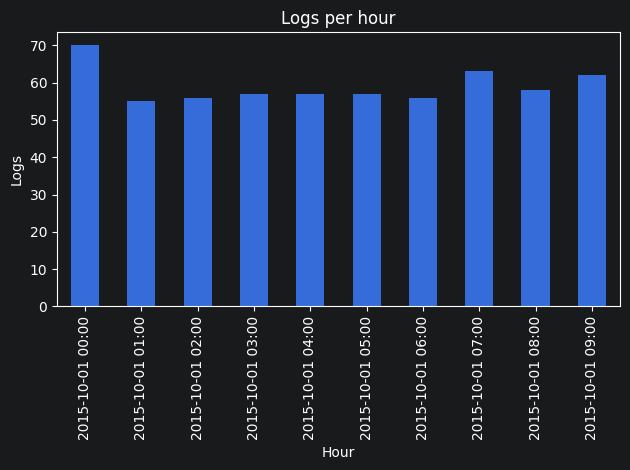

In [31]:
plot_series(logs_per_hour, title="Logs per hour", xlabel="Hour", ylabel="Logs")


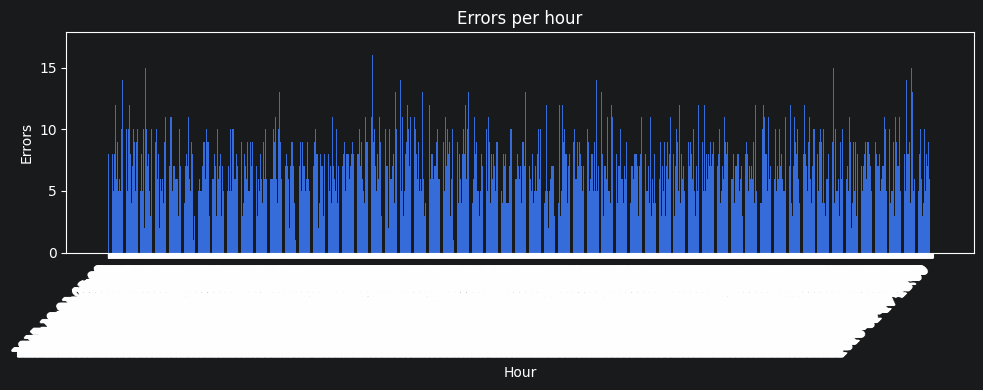

In [32]:
plot_errors_per_hour(result.errors_per_hour, title="Errors per hour")


## 8) Eksport wyników


In [19]:
json_path = REPORTS / "notebook_report.json"
csv_path = REPORTS / "notebook_filtered.csv"
save_report_json(result, str(json_path))
save_filtered_lines_csv(result, str(csv_path))
json_path, csv_path


(WindowsPath('reports/notebook_report.json'),
 WindowsPath('reports/notebook_filtered.csv'))

## 9) OpenMP benchmark + wykresy


In [20]:
cmd = [sys.executable, 'openmp_speedup.py', '--input', INPUT_LOG, '--save-dir', str(REPORTS)]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('OpenMP benchmark failed')


   threads      time   speedup  efficiency
0        1  0.463411  1.000000    1.000000
1        2  0.514183  0.901257    0.450629
2        4  0.564295  0.821221    0.205305
3        8  0.537916  0.861494    0.107687
Figure(1200x400)



In [21]:
df_openmp = pd.read_csv(REPORTS / 'benchmark_openmp.csv')
df_openmp


,threads,time,speedup,efficiency
0,1,0.463411,1.000000,1.000000
1,2,0.514183,0.901257,0.450629
2,4,0.564295,0.821221,0.205305
3,8,0.537916,0.861494,0.107687


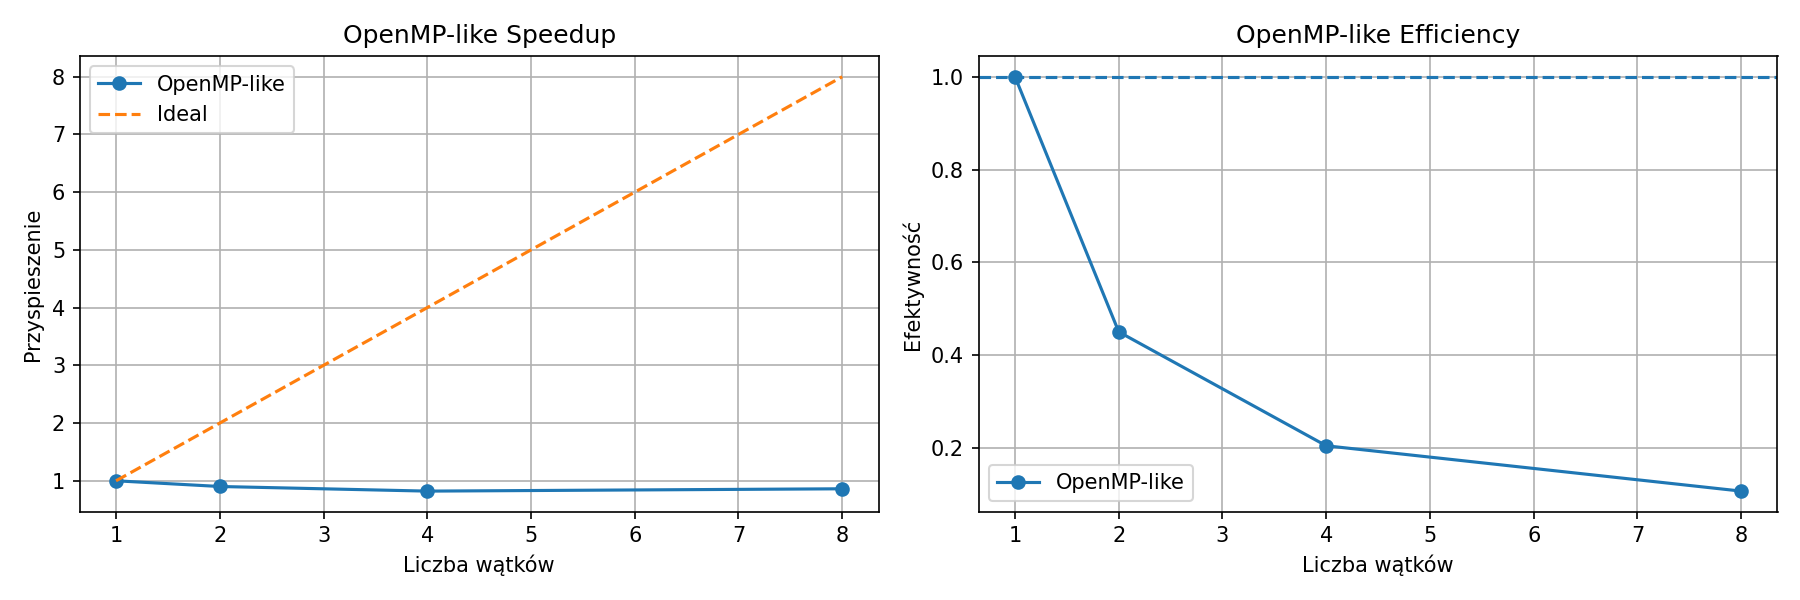

In [22]:
display(Image(filename=str(PLOTS / 'openmp_speedup_efficiency.png')))


## 10) MPI benchmark + wykresy


In [23]:
cmd = [sys.executable, 'mpi_speedup.py', '--input', INPUT_LOG, '--save-dir', str(REPORTS)]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('MPI benchmark failed (sprawdź instalację mpiexec / MPI).')


   processes      time   speedup  efficiency
0          1  0.385581  1.000000    1.000000
1          2  0.297749  1.294988    0.647494
2          4  0.309526  1.245716    0.311429
3          8  0.557014  0.692229    0.086529
Figure(1200x400)



In [24]:
df_mpi = pd.read_csv(REPORTS / 'benchmark_mpi.csv')
df_mpi


,processes,time,speedup,efficiency
0,1,0.385581,1.000000,1.000000
1,2,0.297749,1.294988,0.647494
2,4,0.309526,1.245716,0.311429
3,8,0.557014,0.692229,0.086529


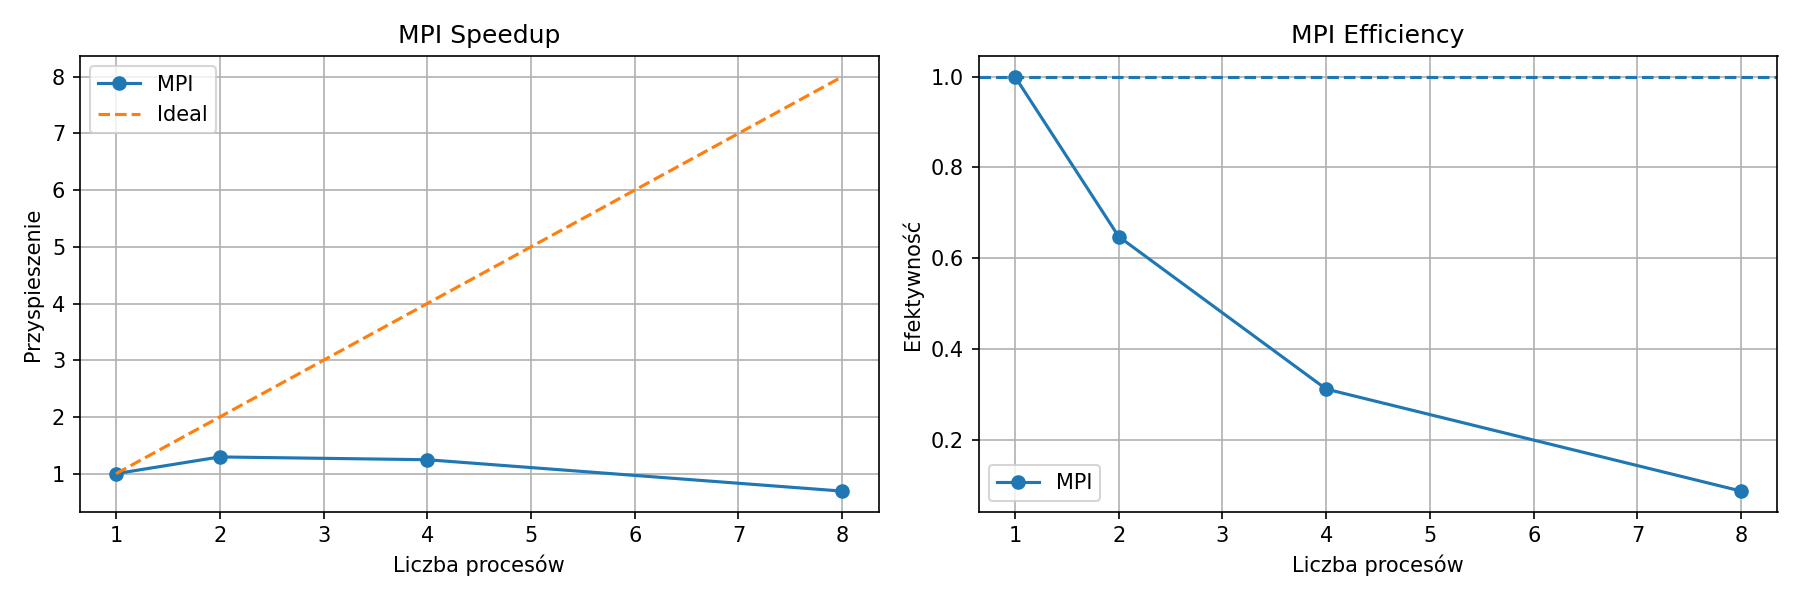

In [25]:
display(Image(filename=str(PLOTS / 'mpi_speedup_efficiency.png')))


## 11) Future work
1. Automatyczne porównania OpenMP-like vs MPI dla wielu rozmiarów danych.
2. Jeden raport końcowy łączący metryki jakości i wydajności.
3. Integracja benchmarków z pipeline CI.
4. Rozszerzenie testów regresyjnych notebooka i raportowania.
